In [1]:
import numpy as np
import matplotlib.pyplot as plt

from resflow.utils.plotting_lobes import custom_cmap, draw_mask_boundary, find_transition_slices, plot_inpaint_comparison

## Optional: Run Sampling
Skip this cell to plot from existing .npy files. Run it to generate fresh samples.

In [2]:
# --- Set SAMPLE = True to generate fresh samples, False to skip ---
SAMPLE = False

if SAMPLE:
    import subprocess, sys
    cmd = [sys.executable, 'sample.py']
    print(f"Running: {' '.join(cmd)}")
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(f"ERROR:\n{result.stderr}")
else:
    print("Skipping sampling — plotting from existing .npy files.")

Skipping sampling — plotting from existing .npy files.


In [3]:
# Load results from .npy files (no need to re-run sample.py)
# Change results_dir to point to a different directory if needed
results_dir = 'results'

gt = np.load(f'{results_dir}/ground_truth.npy')          # (4, 1, 50, 50, 50)
gt_cond = np.load(f'{results_dir}/ground_truth_cond.npy') # (4, 5)

mask_names = ['wells', 'boundaries', 'cross_section', 'combo_wells_bounds', 'combo_all']
masks = {name: np.load(f'{results_dir}/mask_{name}.npy') for name in mask_names}
results = {name: np.load(f'{results_dir}/flow_matching_{name}_50steps.npy') for name in mask_names}

n_samples = gt.shape[0]
print(f"Ground truth: {gt.shape}, samples per scenario: {n_samples}")
for name in mask_names:
    known_frac = masks[name].mean()
    print(f"  {name}: mask known={known_frac:.1%}, result shape={results[name].shape}")

Ground truth: (4, 1, 50, 50, 50), samples per scenario: 4
  wells: mask known=0.1%, result shape=(4, 1, 50, 50, 50)
  boundaries: mask known=18.6%, result shape=(4, 1, 50, 50, 50)
  cross_section: mask known=2.2%, result shape=(4, 1, 50, 50, 50)
  combo_wells_bounds: mask known=14.6%, result shape=(4, 1, 50, 50, 50)
  combo_all: mask known=10.5%, result shape=(4, 1, 50, 50, 50)


Plotting functions (`plot_inpaint_comparison`, `draw_mask_boundary`, `find_transition_slices`) are defined in `resflow.utils.plotting_lobes` and imported above.

## Wells
Well masks: 1-5 vertical or L-shaped wells, 1 voxel wide, variable depth.

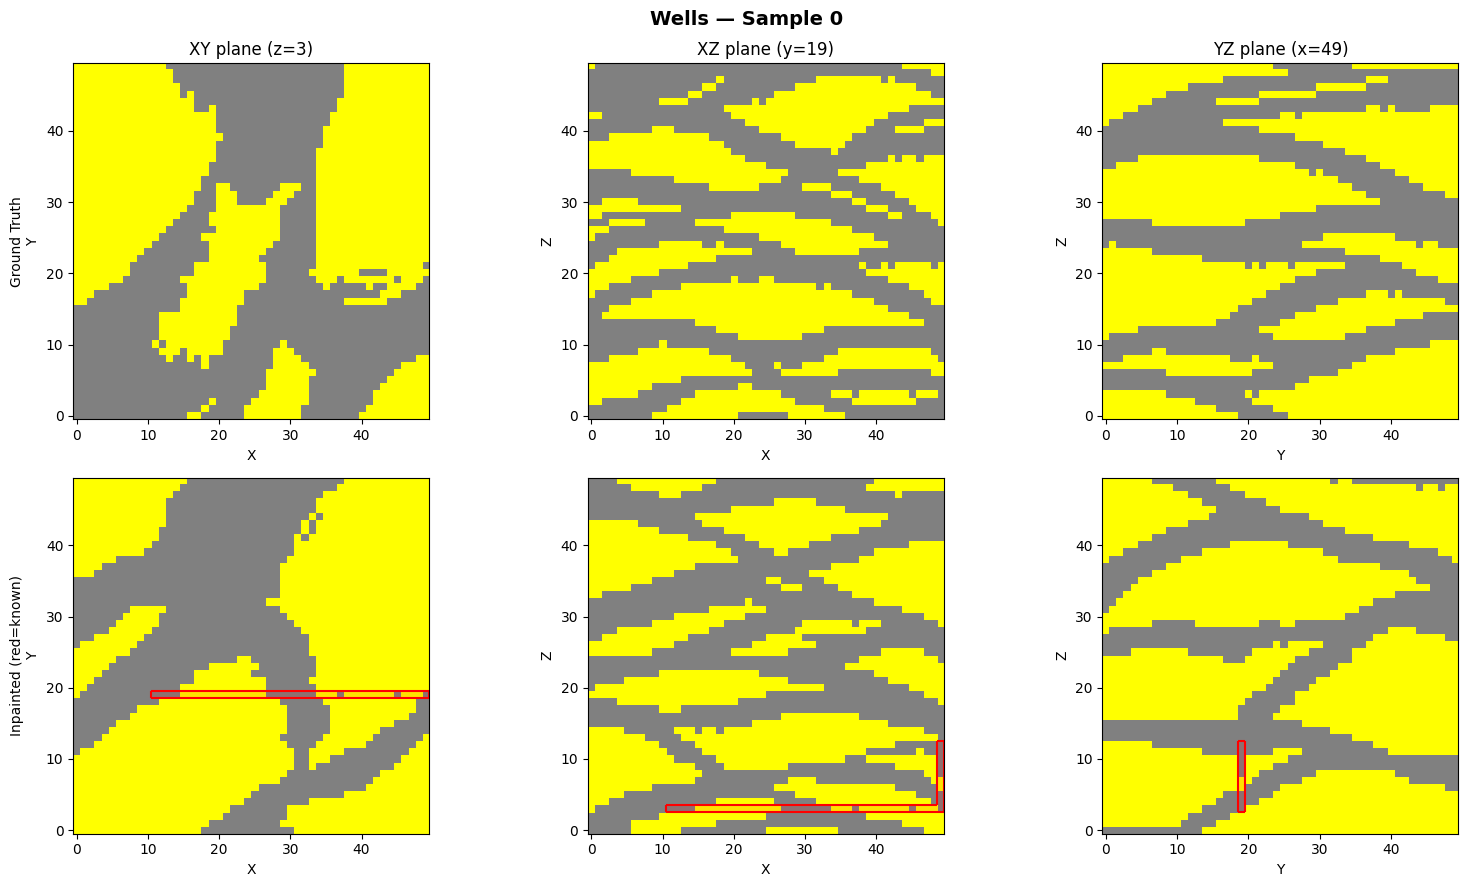

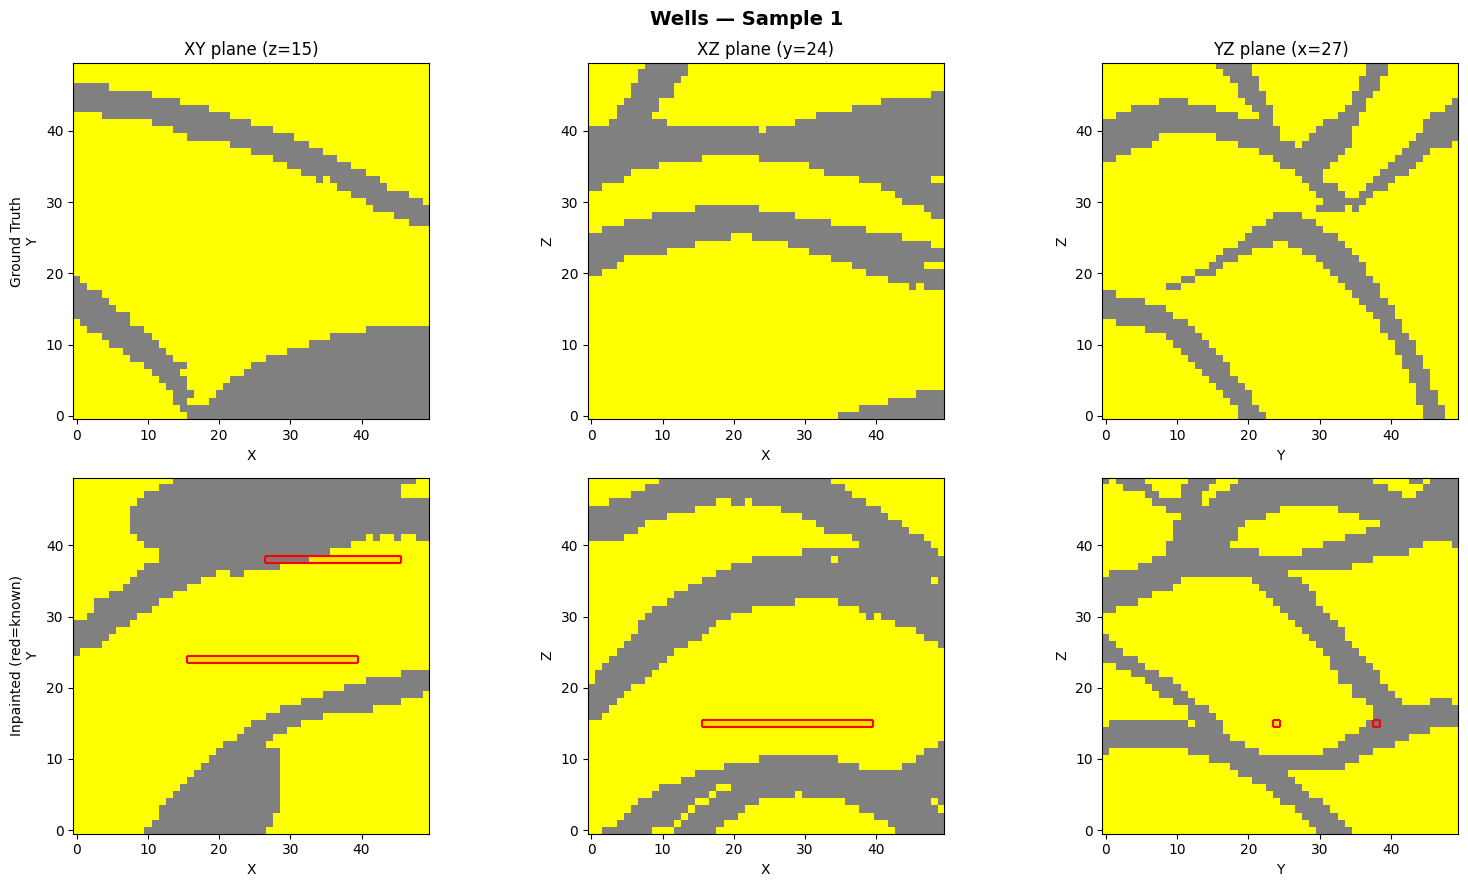

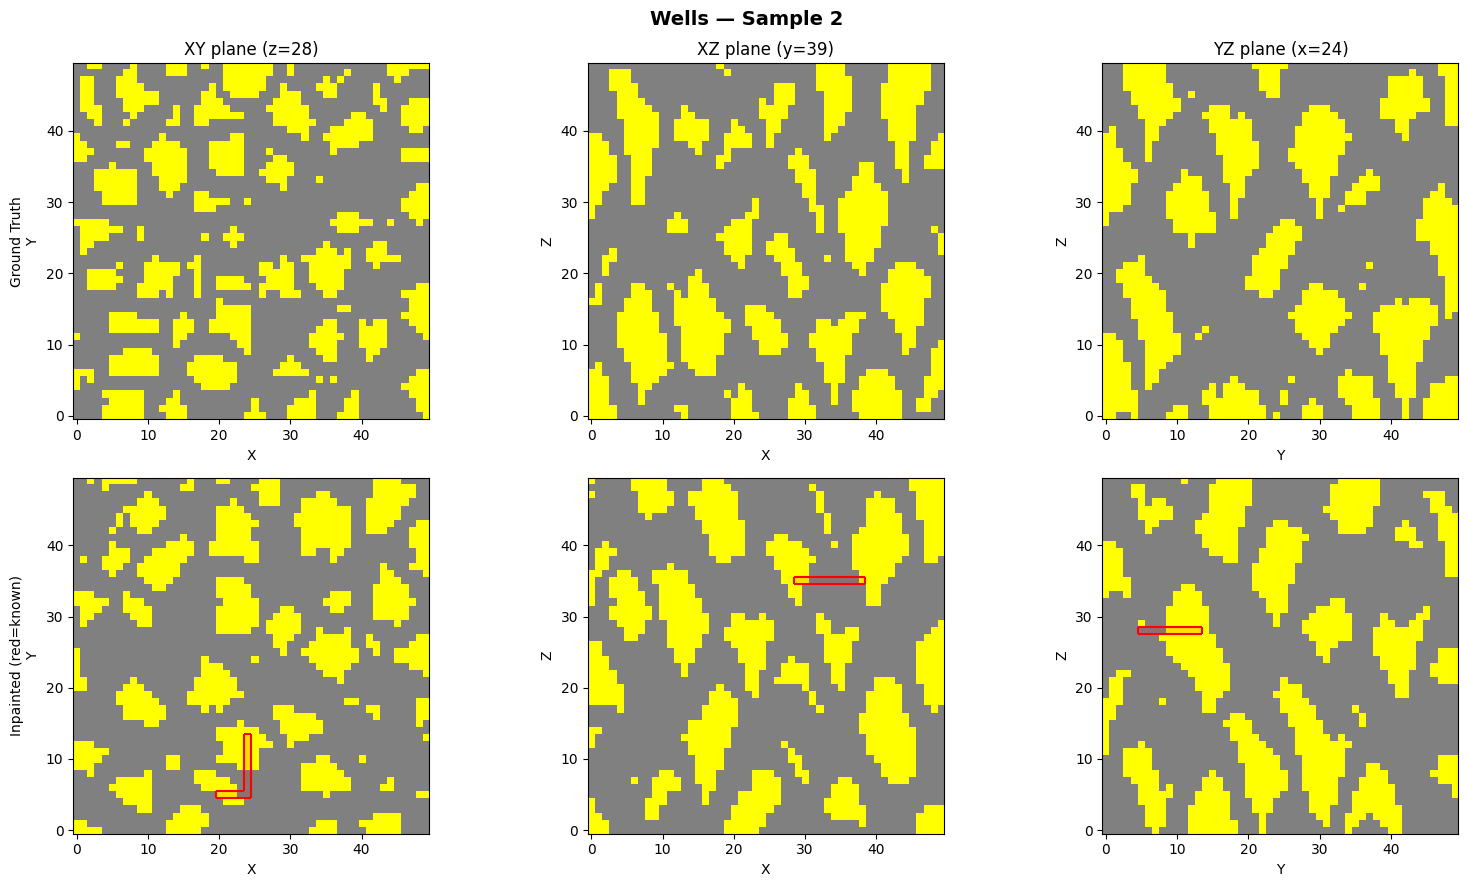

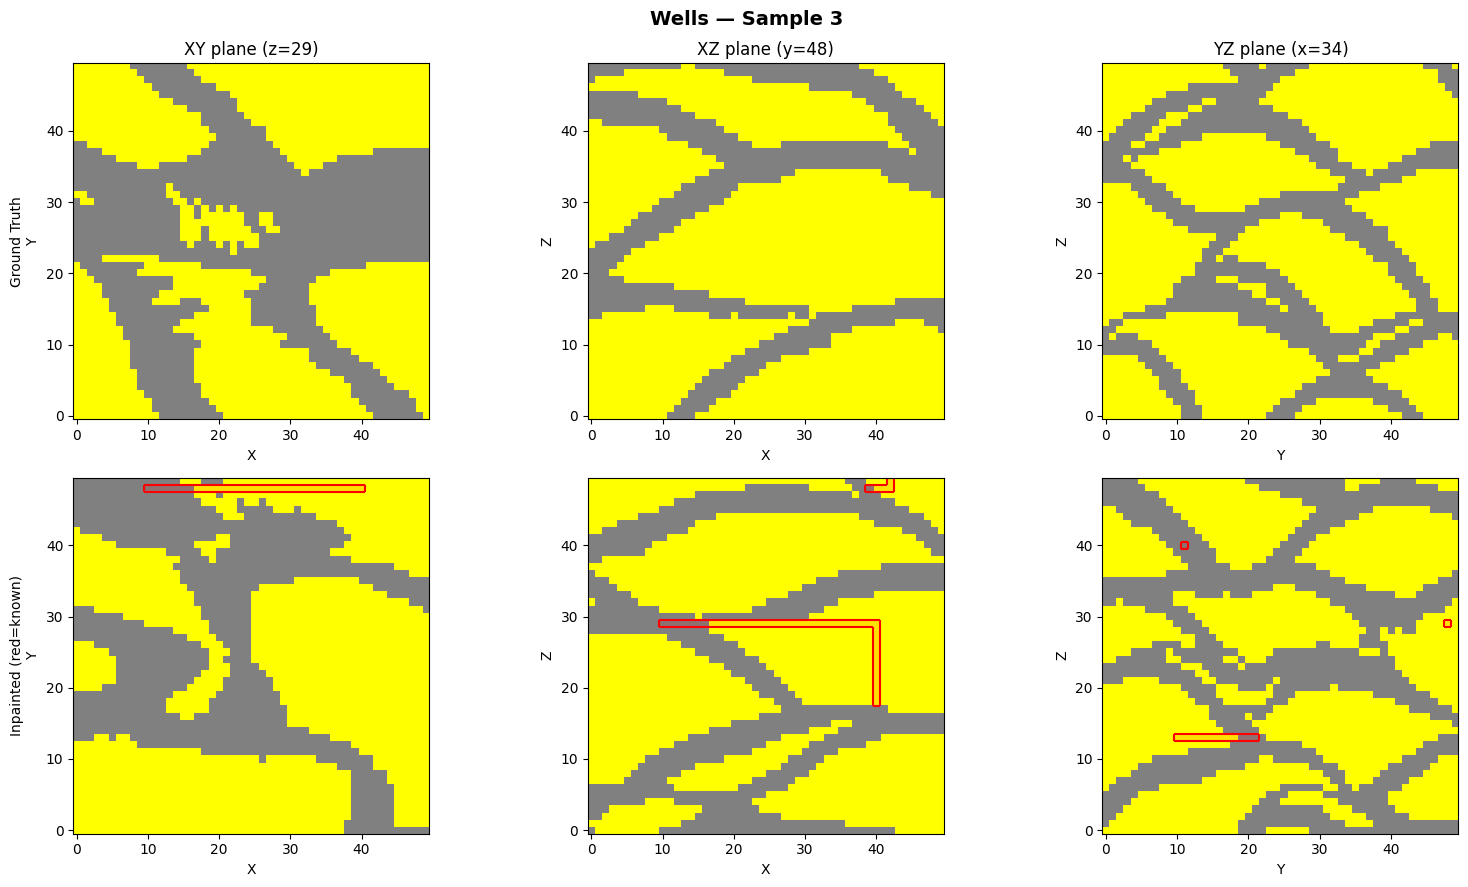

In [4]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['wells'][i, 0], masks['wells'][i, 0],
        f'Wells — Sample {i}'
    )

## Boundaries
Boundary masks: 1-6 faces of the 50x50x50 cube, 1-3 voxels thick. For autoregressive reservoir generation.

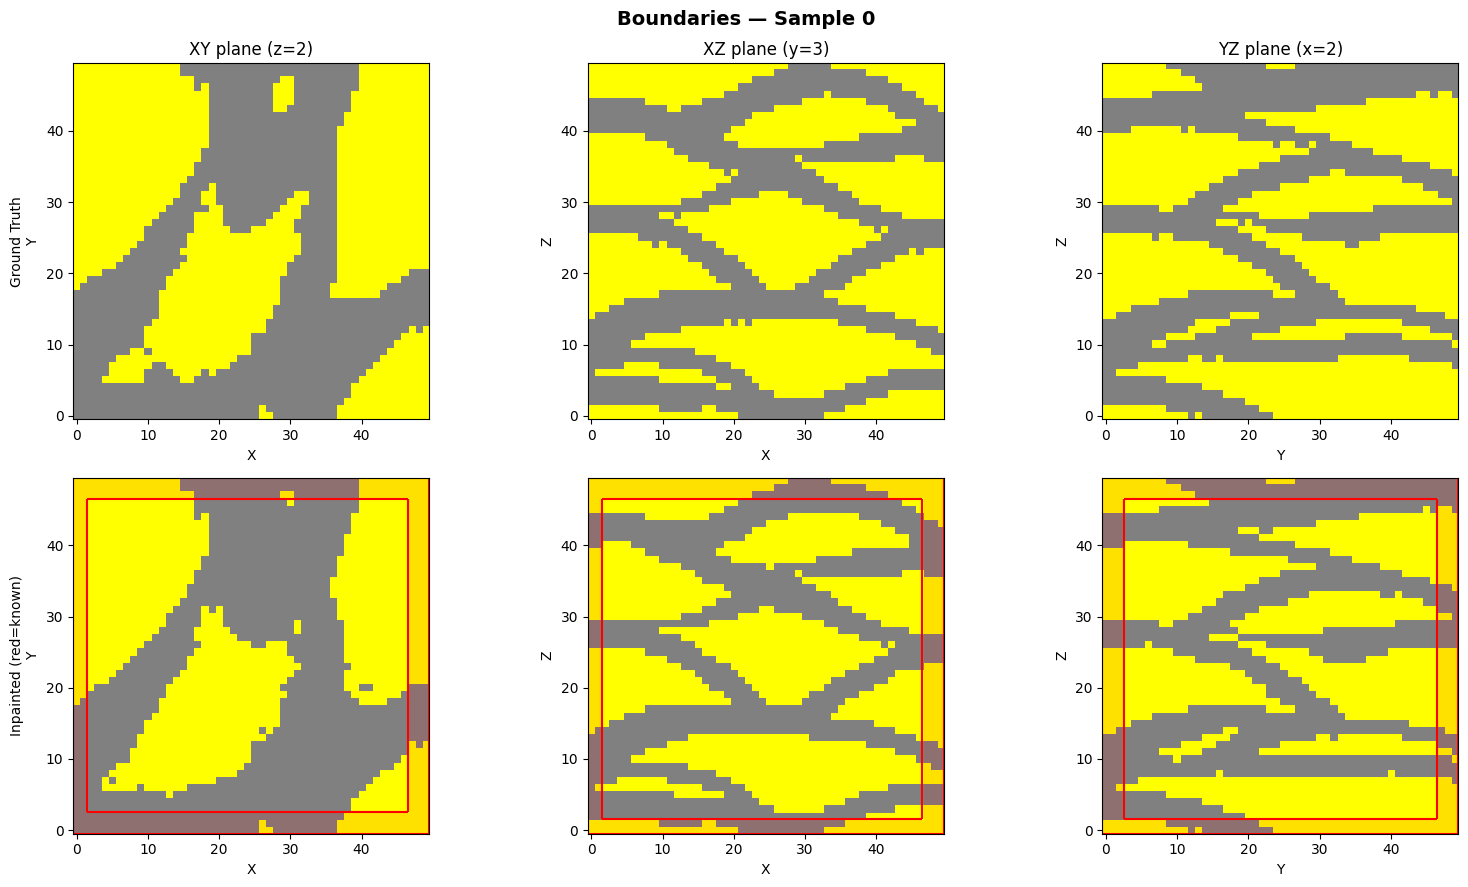

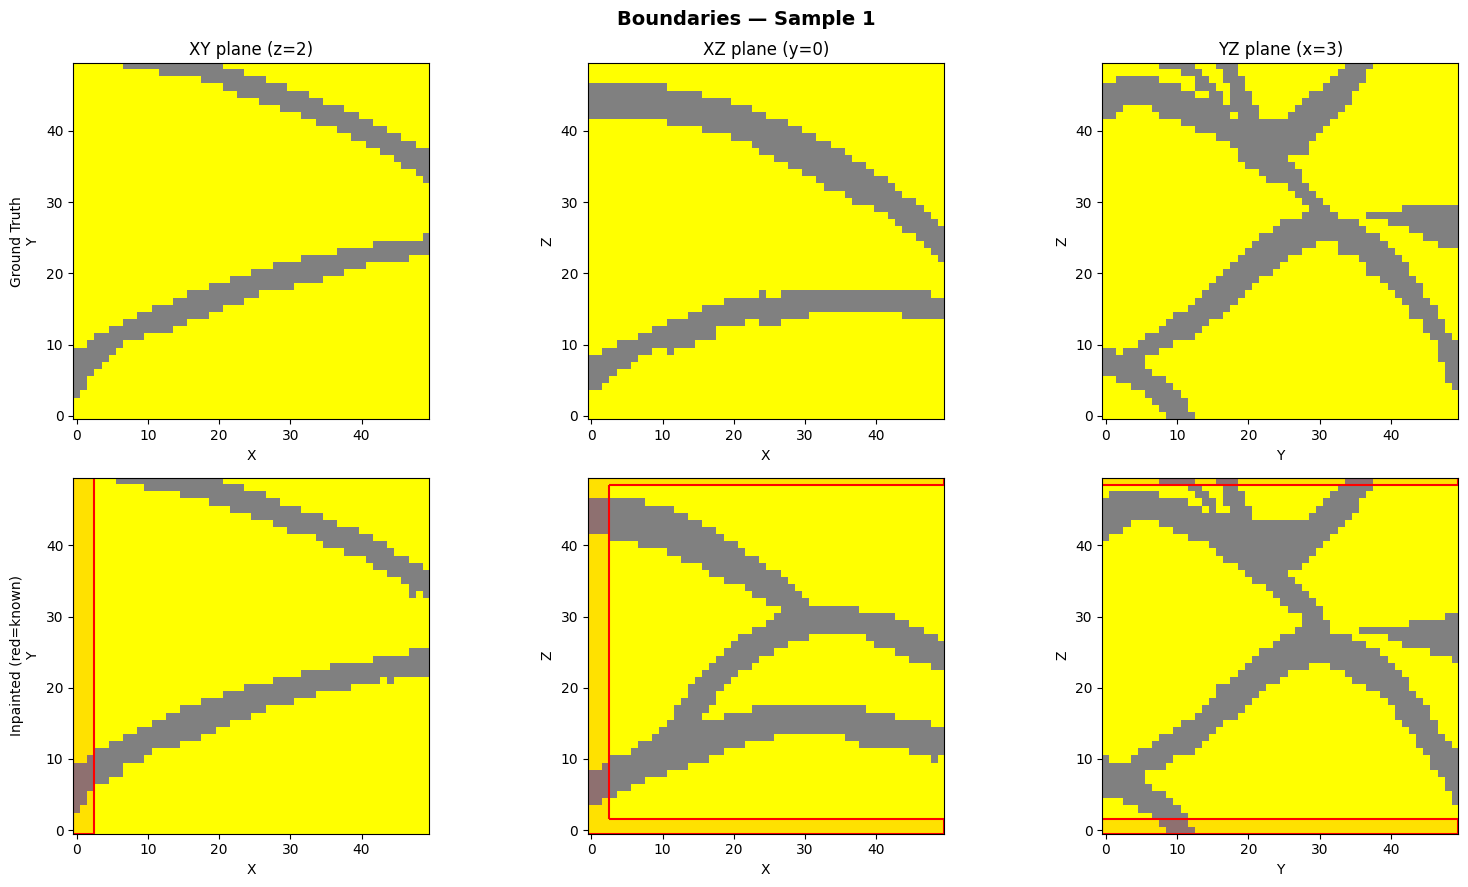

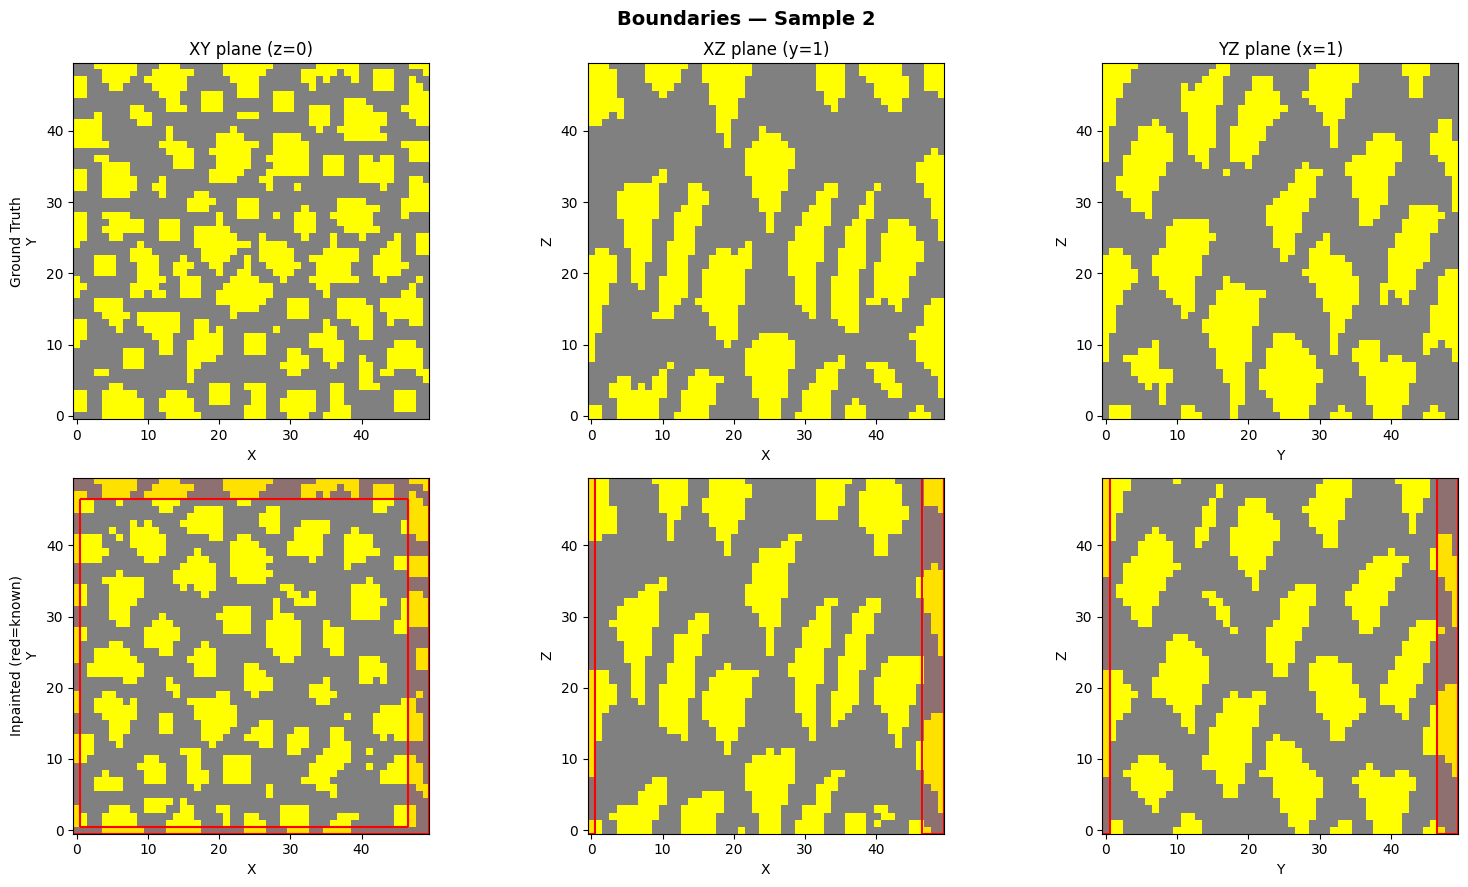

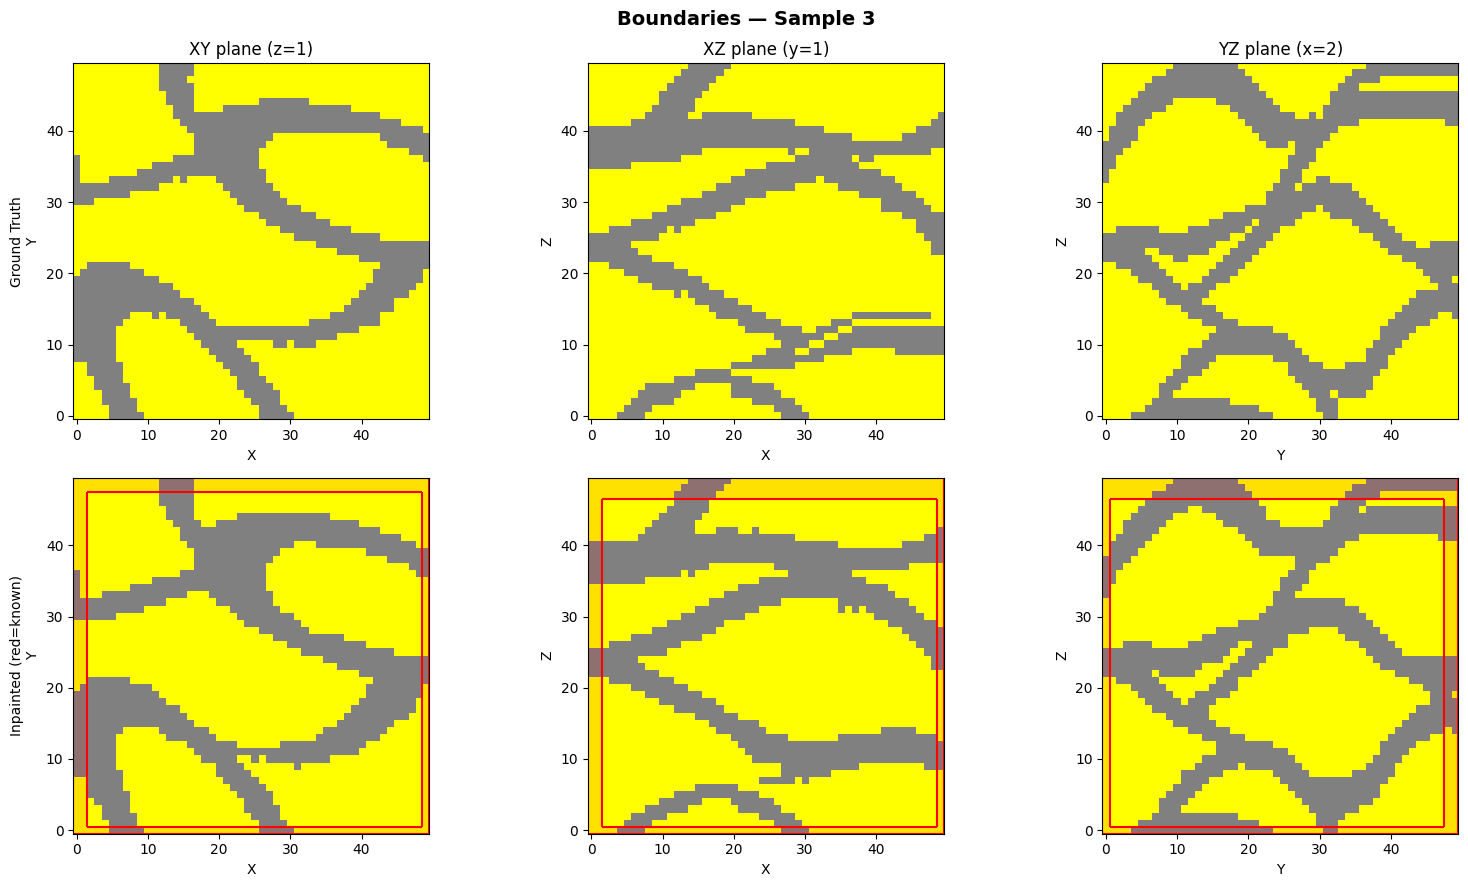

In [5]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['boundaries'][i, 0], masks['boundaries'][i, 0],
        f'Boundaries — Sample {i}'
    )

## Cross-Sections
2D cross-section masks: 1 voxel thick plane at any angle in x-y, up to 30 deg z-tilt. For seismic conditioning.

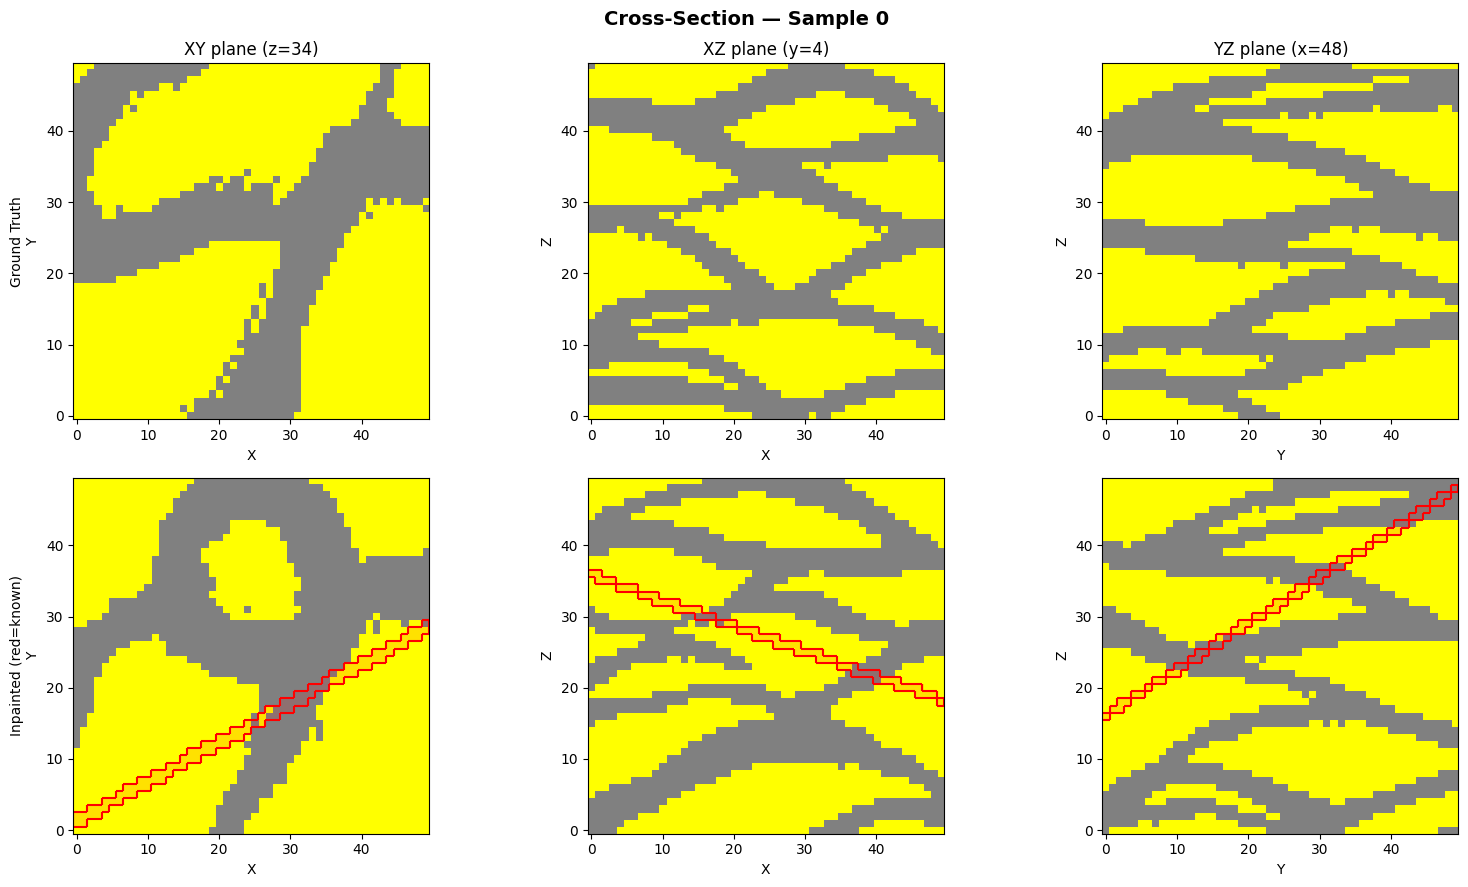

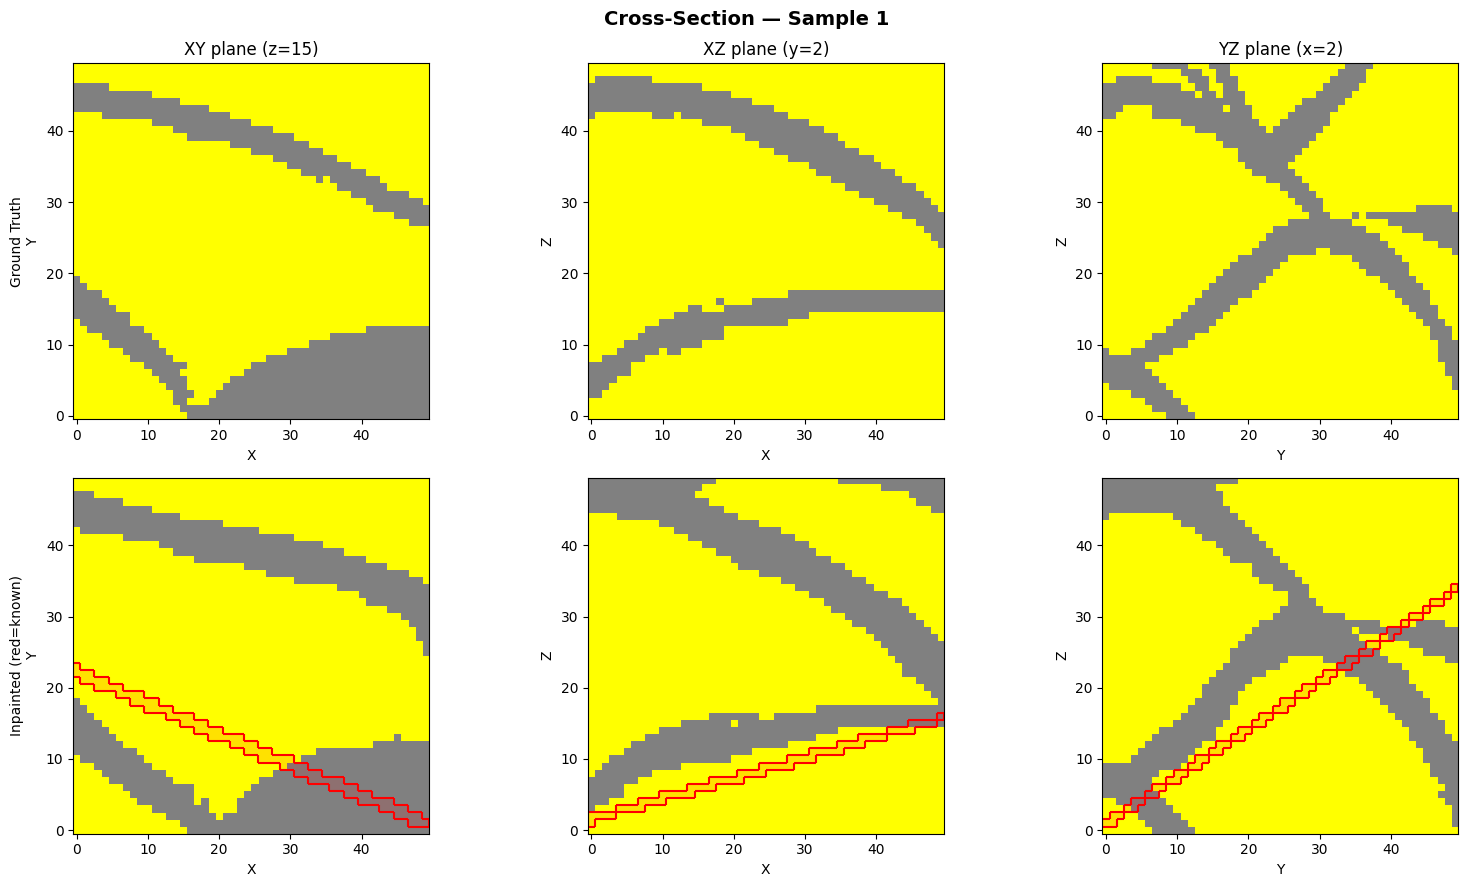

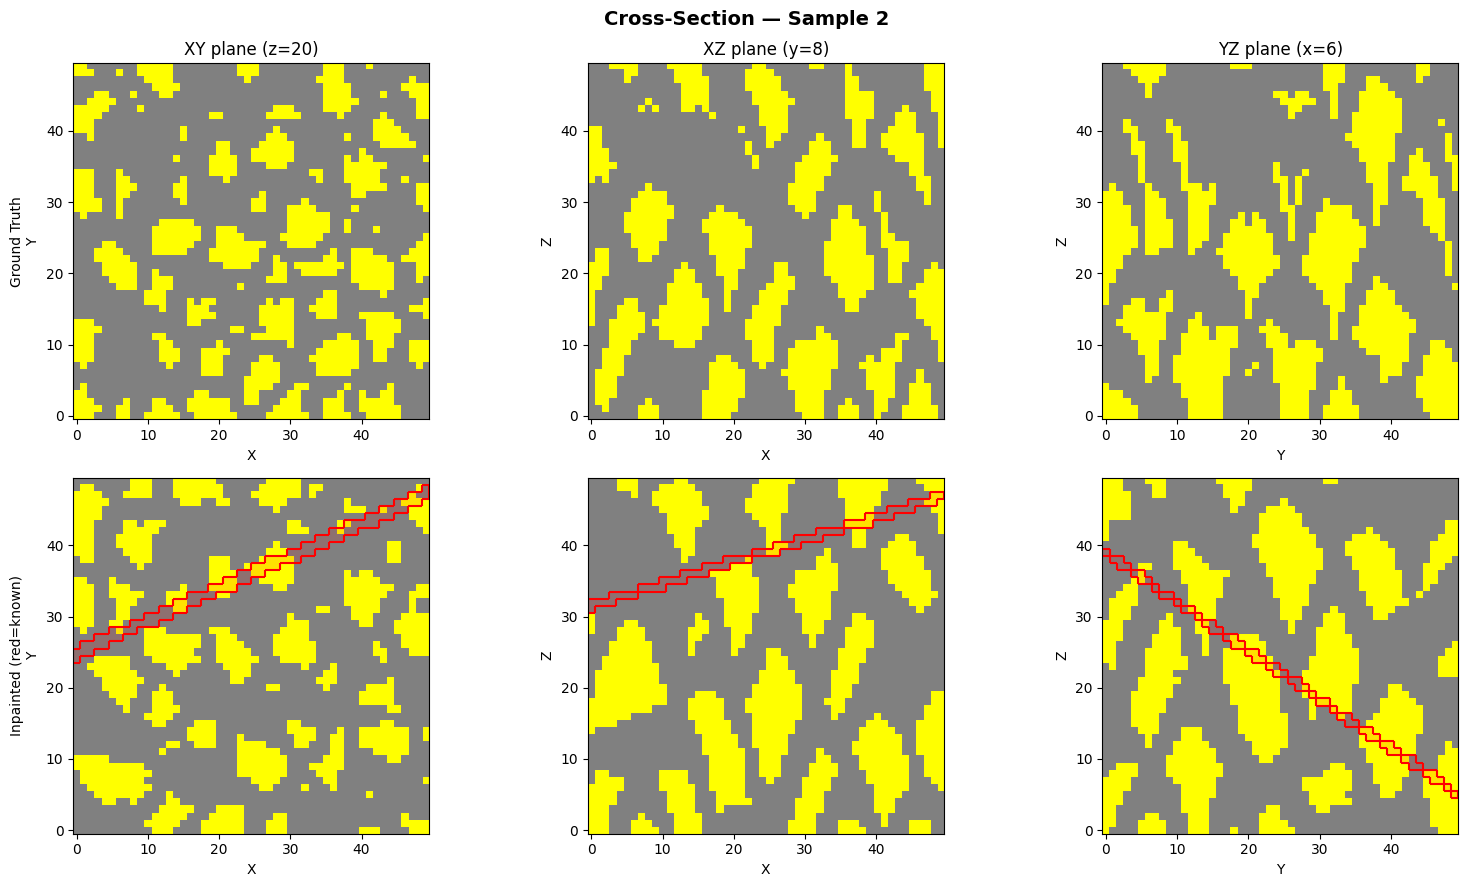

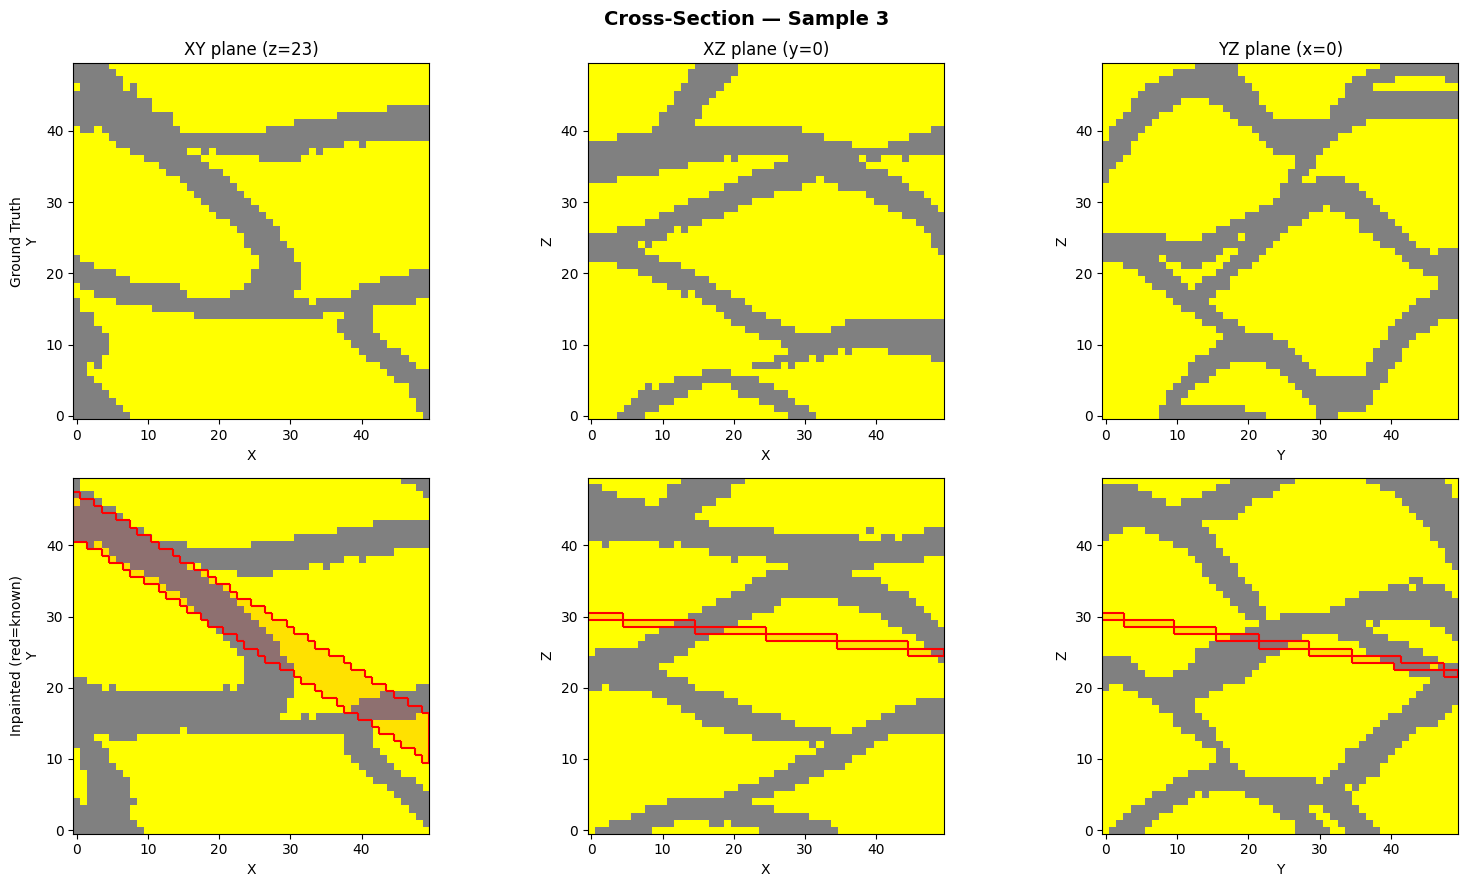

In [6]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['cross_section'][i, 0], masks['cross_section'][i, 0],
        f'Cross-Section — Sample {i}'
    )

## Combinations
Wells + boundaries, and all three mask types combined.

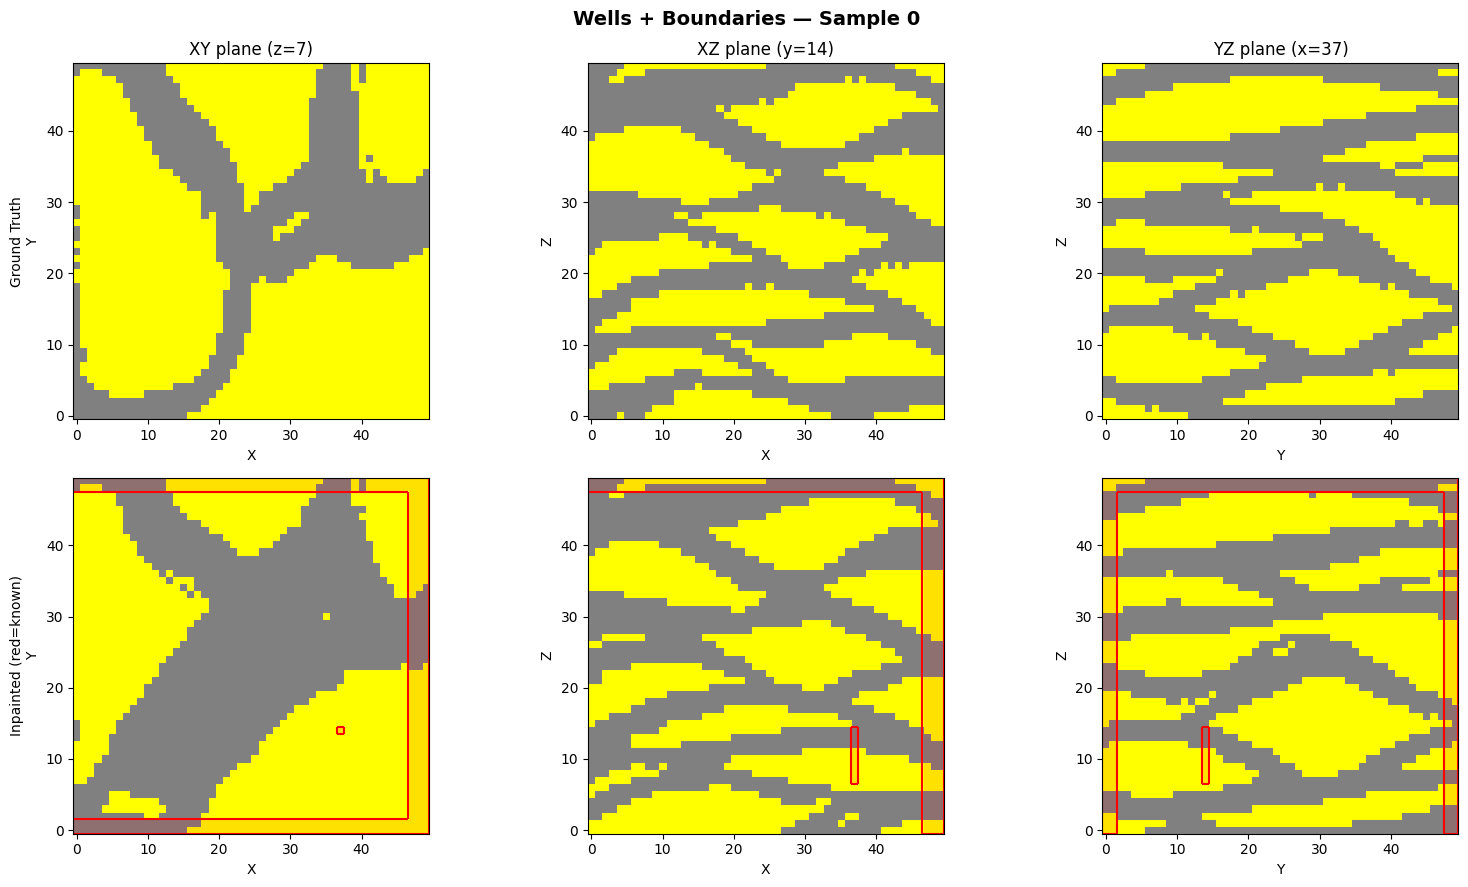

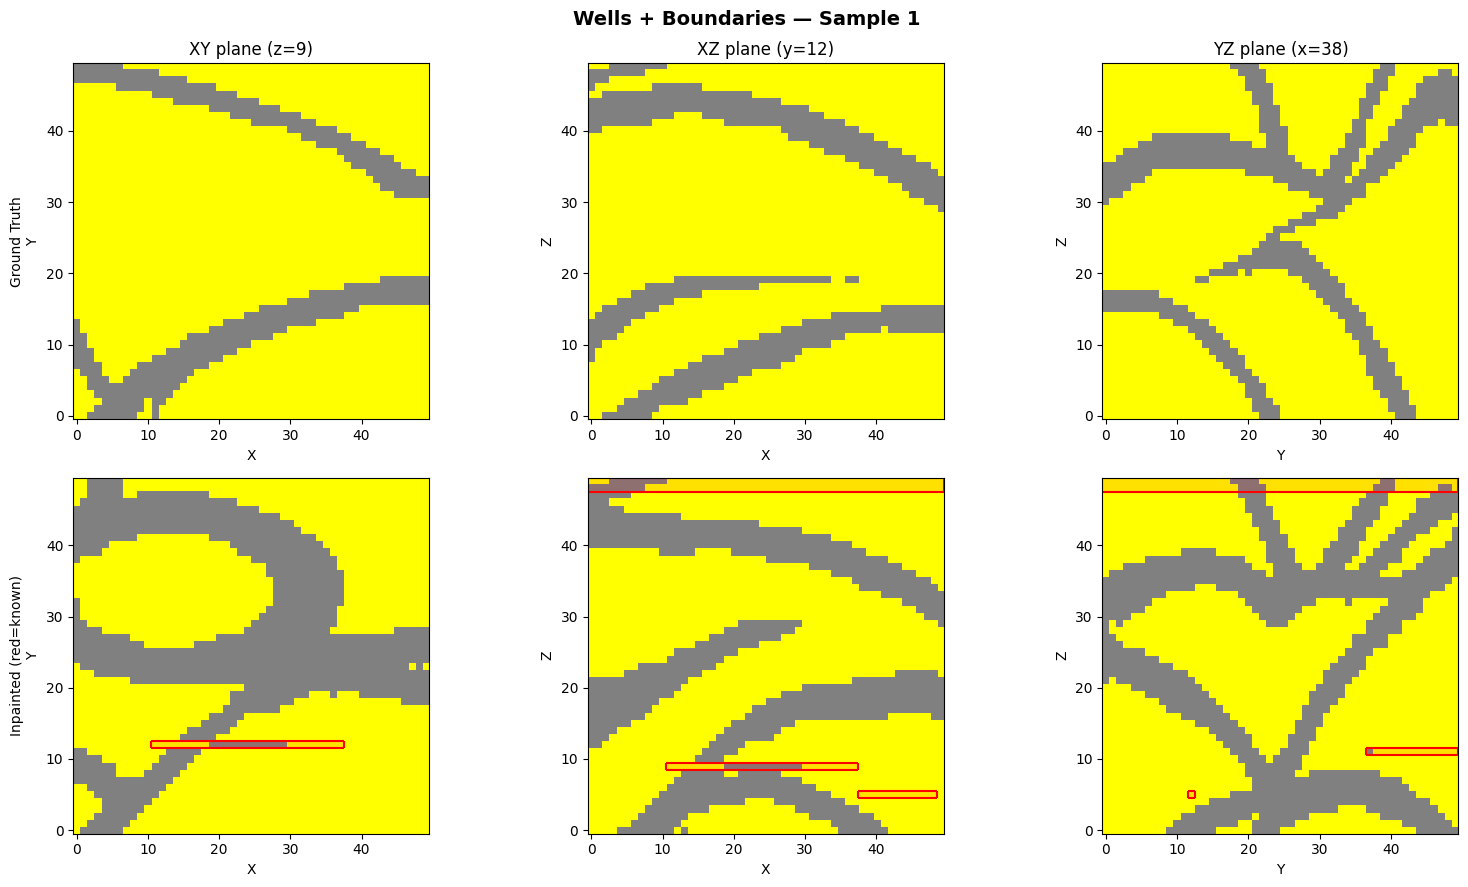

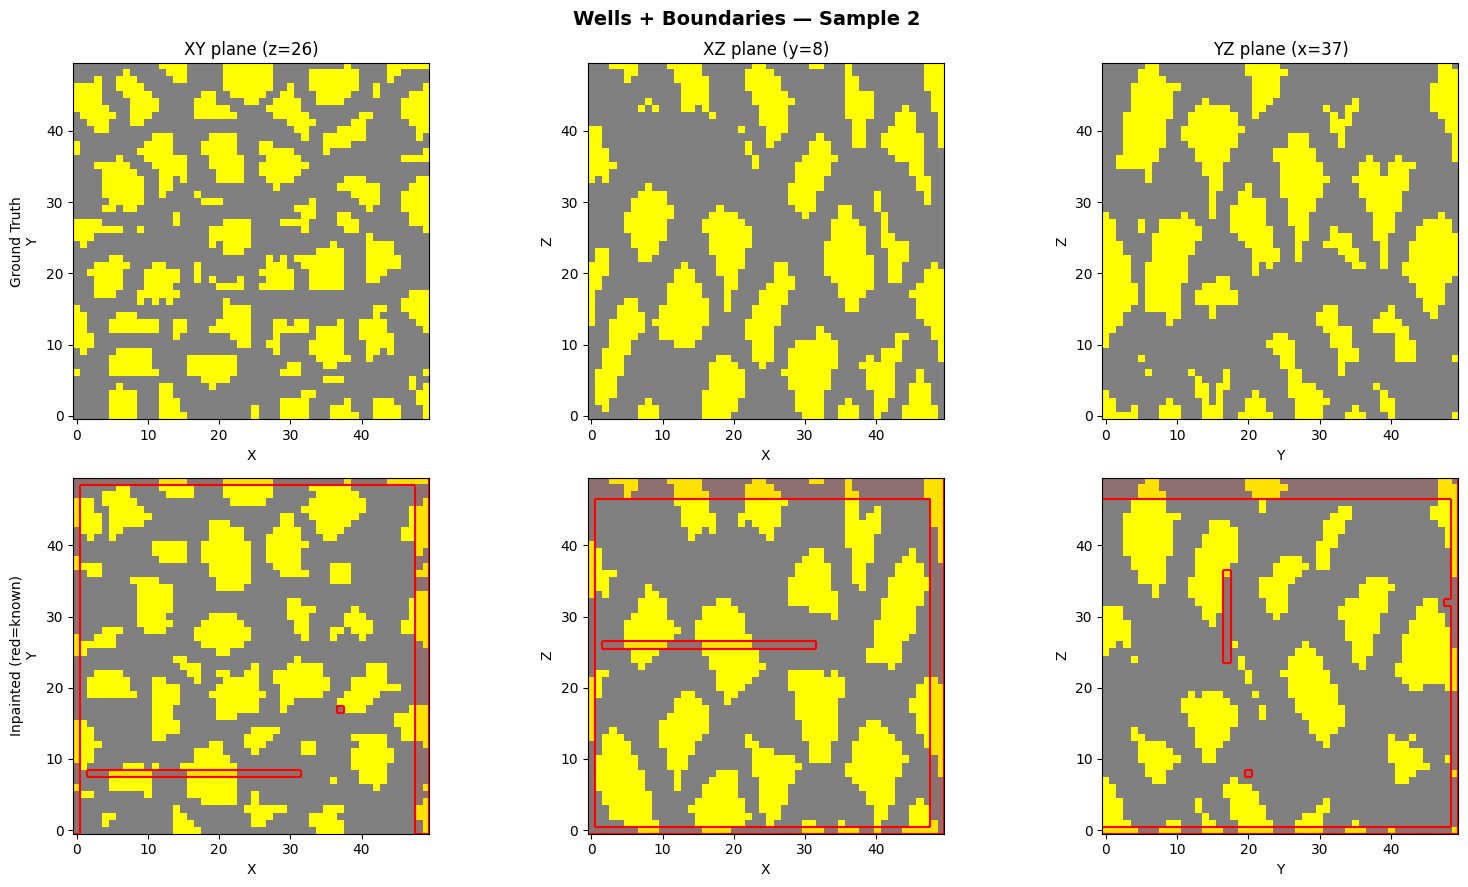

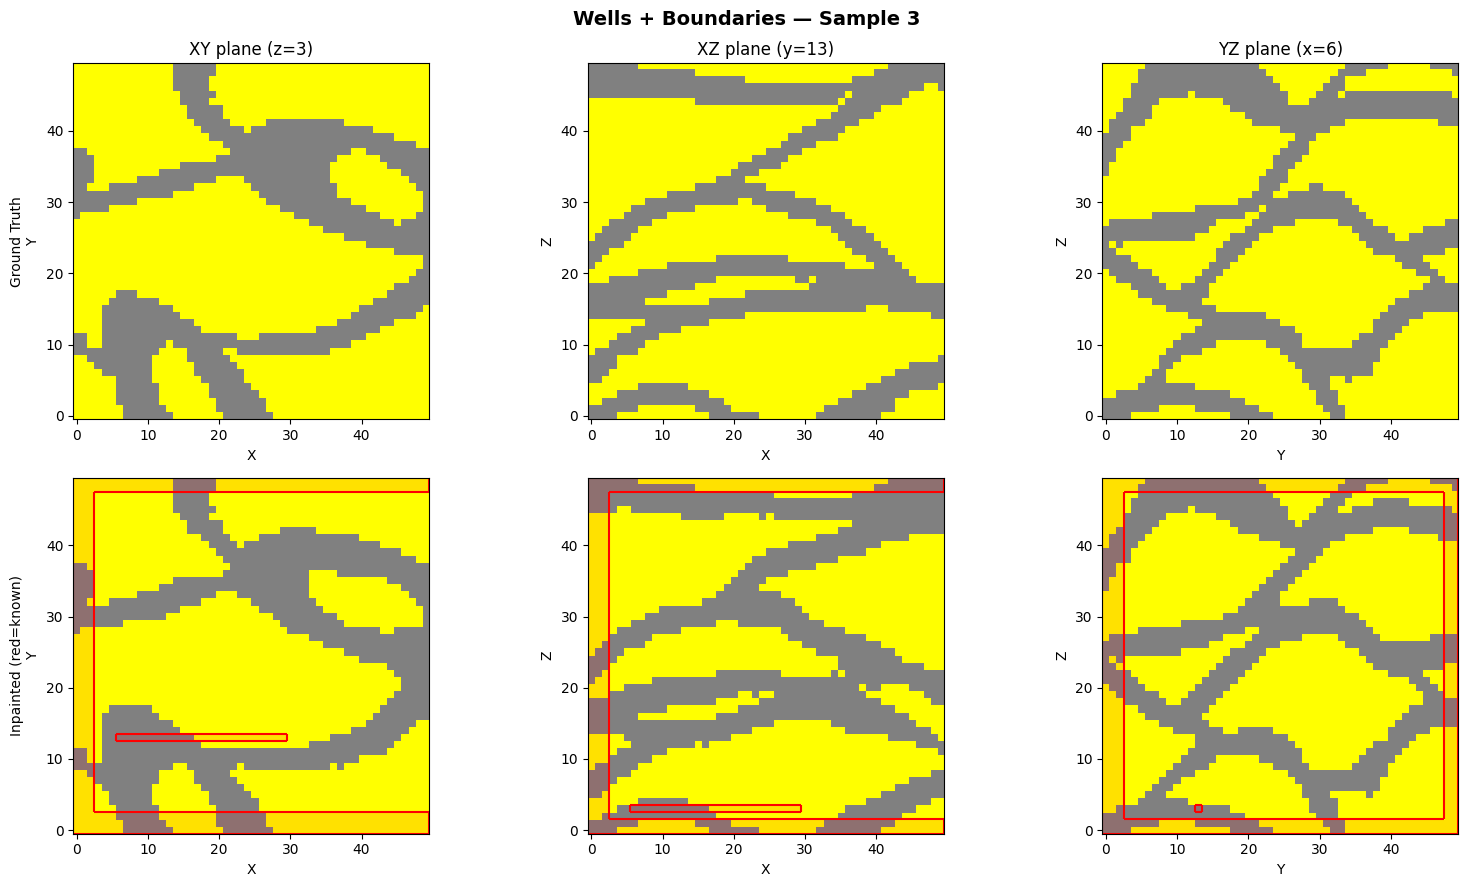

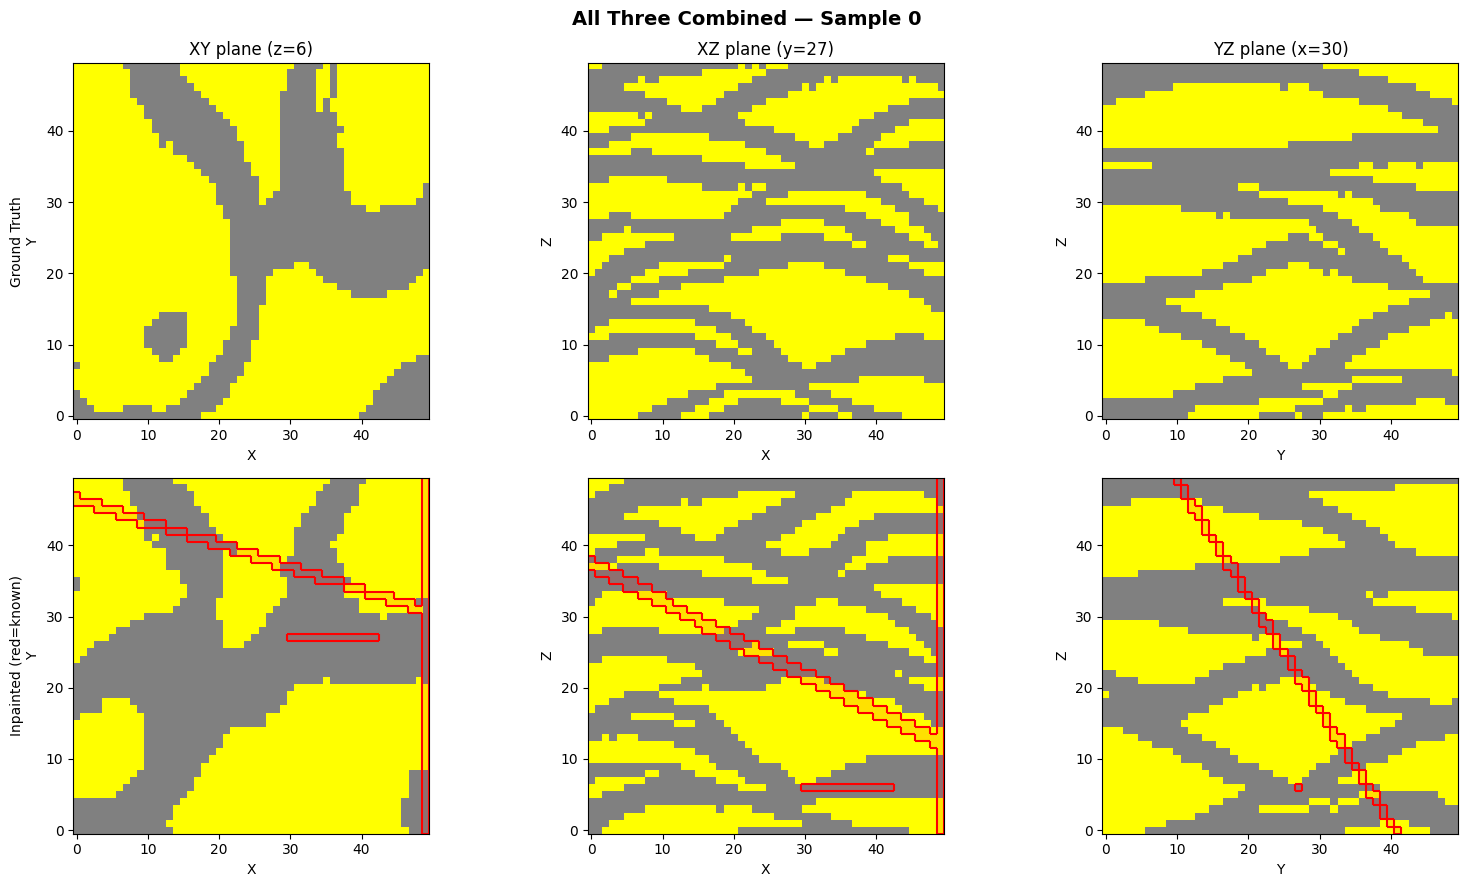

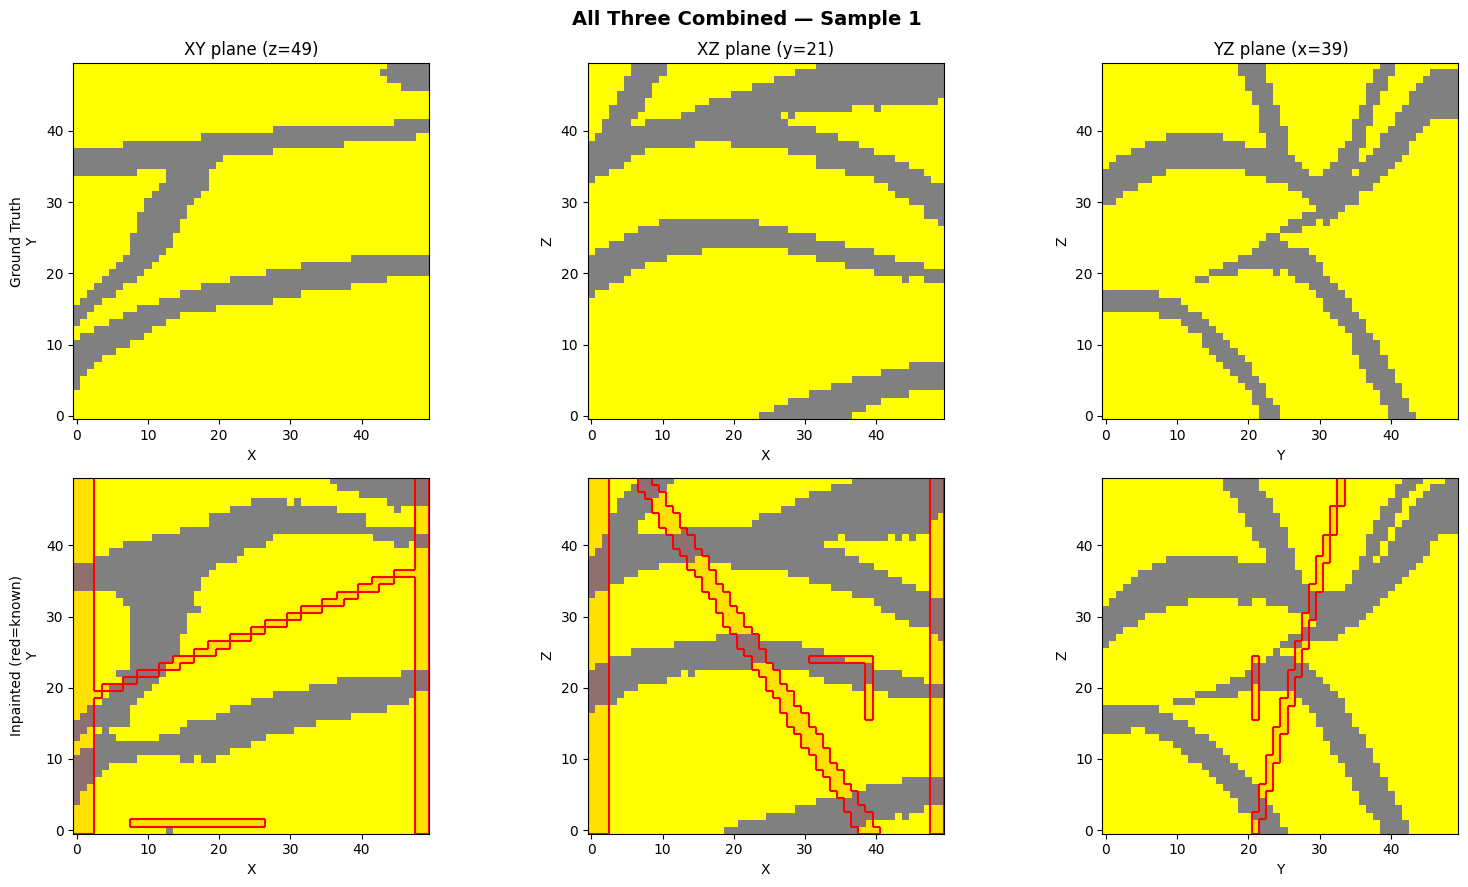

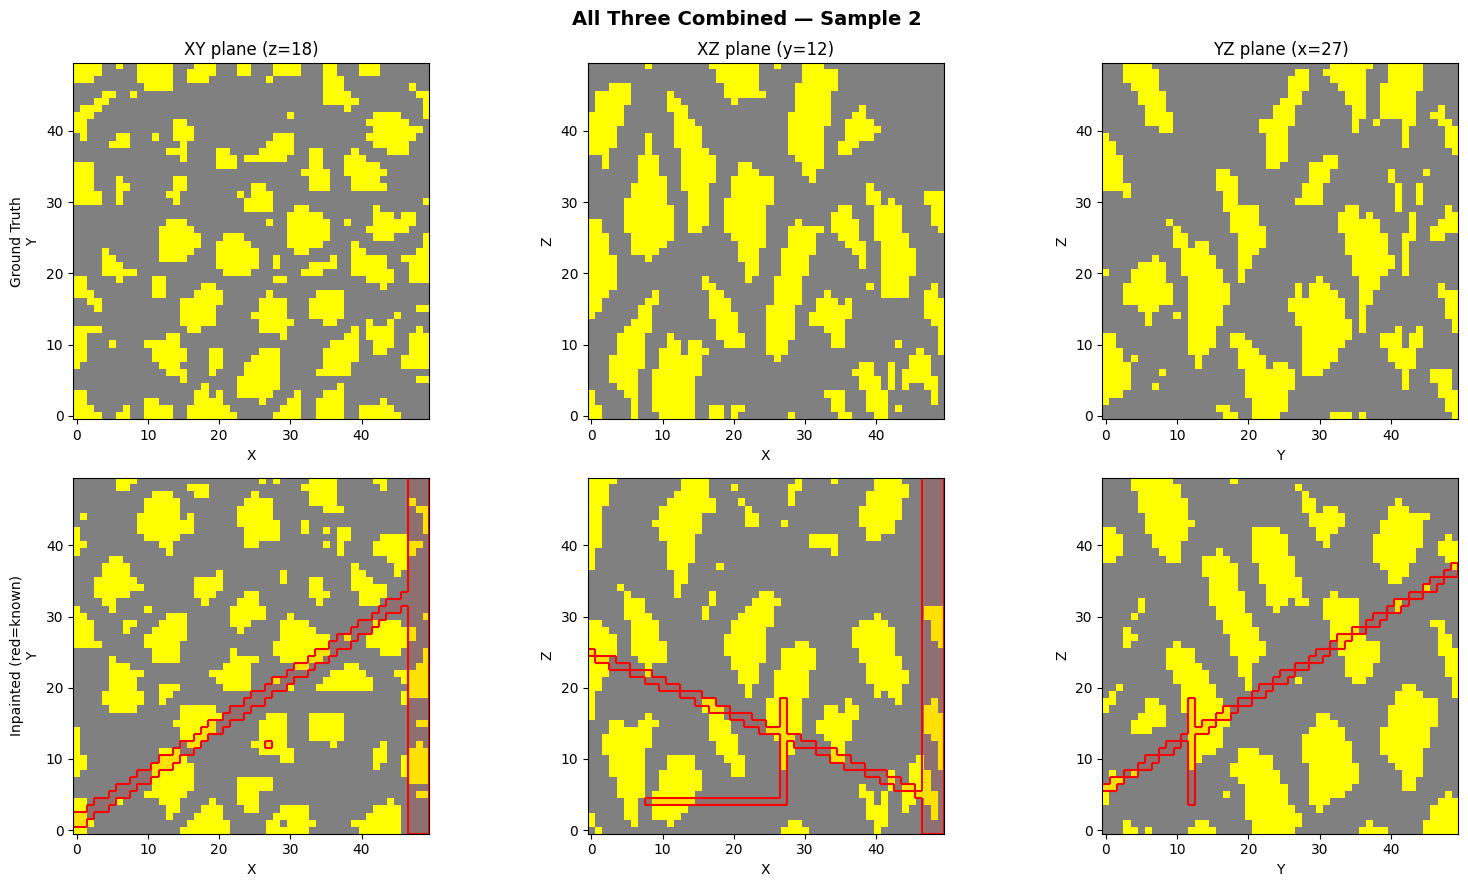

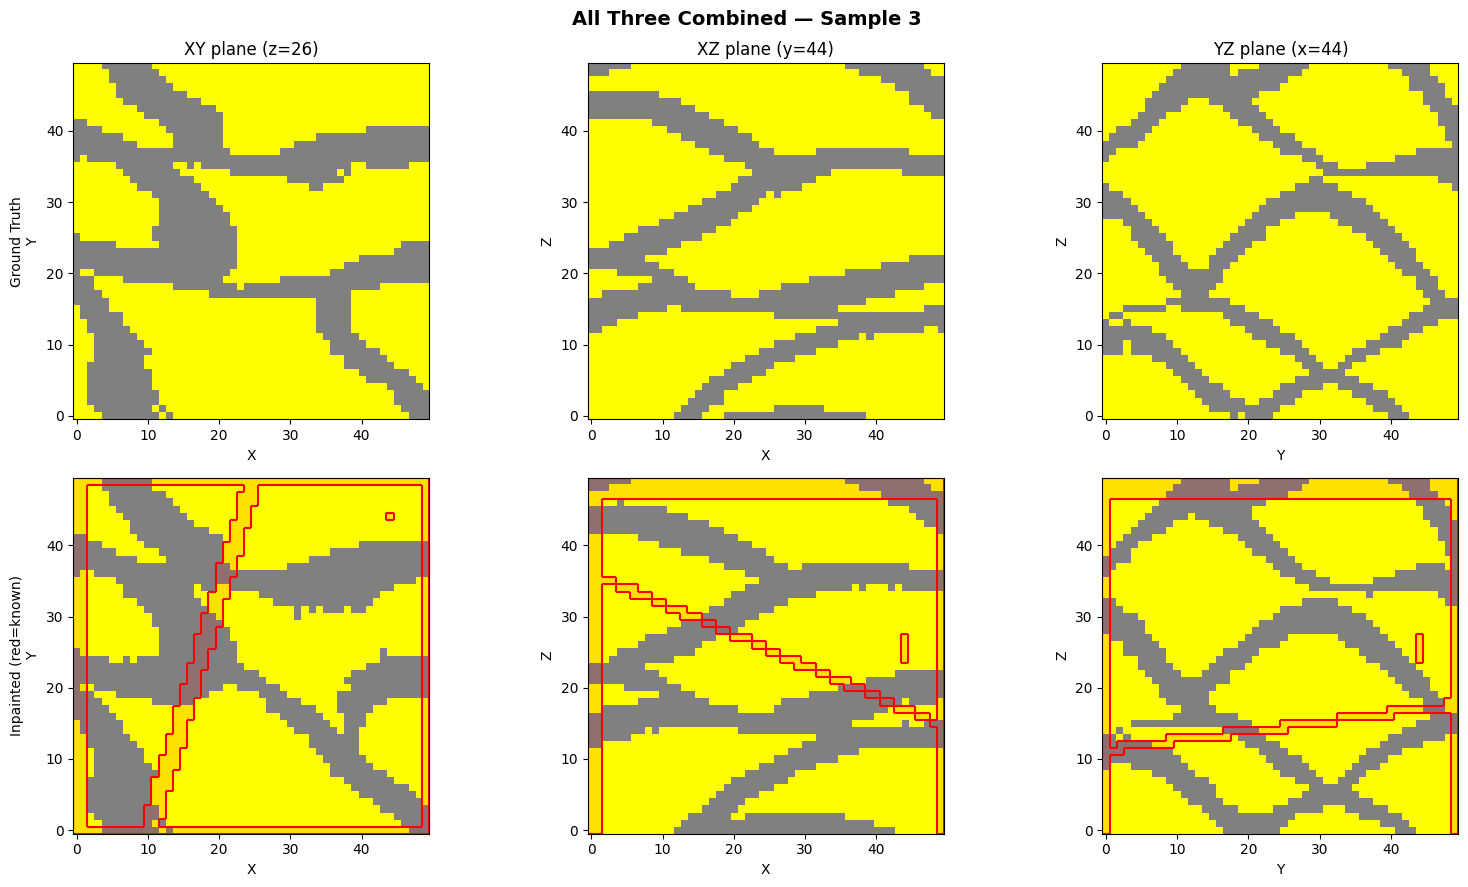

In [7]:
for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['combo_wells_bounds'][i, 0], masks['combo_wells_bounds'][i, 0],
        f'Wells + Boundaries — Sample {i}'
    )

for i in range(n_samples):
    plot_inpaint_comparison(
        gt[i, 0], results['combo_all'][i, 0], masks['combo_all'][i, 0],
        f'All Three Combined — Sample {i}'
    )

## Summary Statistics
Known-region match rate and NTG comparison per mask type.

In [8]:
print(f"{'Mask Type':<25} {'Known %':>8} {'Match Rate':>11} {'GT NTG':>8} {'Result NTG':>11}")
print("-" * 68)
for name in mask_names:
    m = masks[name]
    r = results[name]
    known_frac = m.mean()
    mask_bool = m > 0.5
    match = (gt[mask_bool] == r[mask_bool]).mean() if mask_bool.any() else 1.0
    gt_ntg = gt.mean()
    res_ntg = r.mean()
    print(f"{name:<25} {known_frac:>7.1%} {match:>10.1%} {gt_ntg:>8.3f} {res_ntg:>11.3f}")

Mask Type                  Known %  Match Rate   GT NTG  Result NTG
--------------------------------------------------------------------
wells                        0.1%     100.0%    0.569       0.533
boundaries                  18.6%     100.0%    0.569       0.535
cross_section                2.2%     100.0%    0.569       0.543
combo_wells_bounds          14.6%     100.0%    0.569       0.529
combo_all                   10.5%     100.0%    0.569       0.542
